# 🧠 Binary Pattern Learning Using a Restricted Boltzmann Machine (RBM)
### Academic Project: Energy-Based Neural Networks & Associative Denoising Memory
---

**Author:** Academic Project  
**Domain:** Machine Learning / Generative Models / Associative Memory  
**Key Concepts:** Restricted Boltzmann Machine (RBM), Contrastive Divergence (CD-1), Gibbs Sampling, Energy Minimization, Pattern Denoising  

---

## 📌 1. Project Overview & Theoretical Foundations

A **Restricted Boltzmann Machine (RBM)** is a two-layer, bipartite, undirected graphical energy-based neural network consisting of:
1. **Visible Layer ($v \in \{0, 1\}^V$):** 25 binary units representing the pixels of a $5 \times 5$ image.
2. **Hidden Layer ($h \in \{0, 1\}^H$):** 24 latent stochastic feature detectors.

Because there are **no intra-layer connections** (visible-to-visible and hidden-to-hidden are restricted), the hidden units are conditionally independent given the visible units, and vice-versa.

### 📐 Mathematical Formulation

#### 1. Energy Function:
$$E(v, h) = - \sum_{i=1}^{V} a_i v_i - \sum_{j=1}^{H} b_j h_j - \sum_{i=1}^{V} \sum_{j=1}^{H} v_i W_{ij} h_j = - v^T W h - a^T v - b^T h$$

#### 2. Conditional Activation Probabilities:
$$P(h_j = 1 \mid v) = \sigma\left(b_j + \sum_{i=1}^V v_i W_{ij}\right)$$
$$P(v_i = 1 \mid h) = \sigma\left(a_i + \sum_{j=1}^H h_j W_{ij}\right)$$
where $\sigma(z) = \frac{1}{1 + e^{-z}}$ is the logistic sigmoid activation.

#### 3. Contrastive Divergence (CD-1) Learning:
$$\Delta W = \eta \left( v^{(0)T} P(h^{(0)} \mid v^{(0)}) - v^{(1)T} P(h^{(1)} \mid v^{(1)}) \right) - \lambda W + \gamma \Delta W_{\text{prev}}$$

#### 4. Analytical Free Energy:
$$F(v) = - v^T a - \sum_{j=1}^H \ln\left(1 + e^{b_j + v W_{\cdot, j}}\right)$$


## 🛠️ Step 1: Environment Setup & Library Imports

In [1]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Set random seed for exact reproducibility
SEED = 42
np.random.seed(SEED)

# Configure Matplotlib styling
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.edgecolor': '#cbd5e1',
    'axes.linewidth': 1.2,
    'grid.color': '#f1f5f9',
    'figure.facecolor': '#ffffff',
    'axes.facecolor': '#ffffff',
    'figure.dpi': 120
})

print(f"NumPy: {np.__version__} | Pandas: {pd.__version__} | Matplotlib: {plt.matplotlib.__version__}")


NumPy: 1.26.4 | Pandas: 3.0.0 | Matplotlib: 3.10.8


## 📊 Step 2: Load Dataset & Extract Clean Canonical Patterns

In [2]:
dataset_path = os.path.join('..', 'dataset', 'binary_patterns_dataset.csv')
if not os.path.exists(dataset_path):
    dataset_path = 'binary_patterns_dataset.csv'

df = pd.read_csv(dataset_path)
pixel_cols = [c for c in df.columns if c.startswith('pixel_')]

# Extract the 8 clean canonical prototypes
canonical_dict = {}
for p_name, group in df.groupby('pattern'):
    avg = group[pixel_cols].mean().values
    canonical_dict[p_name] = (avg >= 0.5).astype(np.float64)

pattern_names = list(canonical_dict.keys())
print(f"Loaded dataset with {len(df)} rows across {len(canonical_dict)} pattern classes:")
print(f"Patterns: {', '.join(pattern_names)}")


Loaded dataset with 400 rows across 8 pattern classes:
Patterns: DIAMOND, H_LINE, L, PLUS, SQUARE, T, V_LINE, X


## 🎨 Step 3: Visualize Ground-Truth 5×5 Binary Patterns

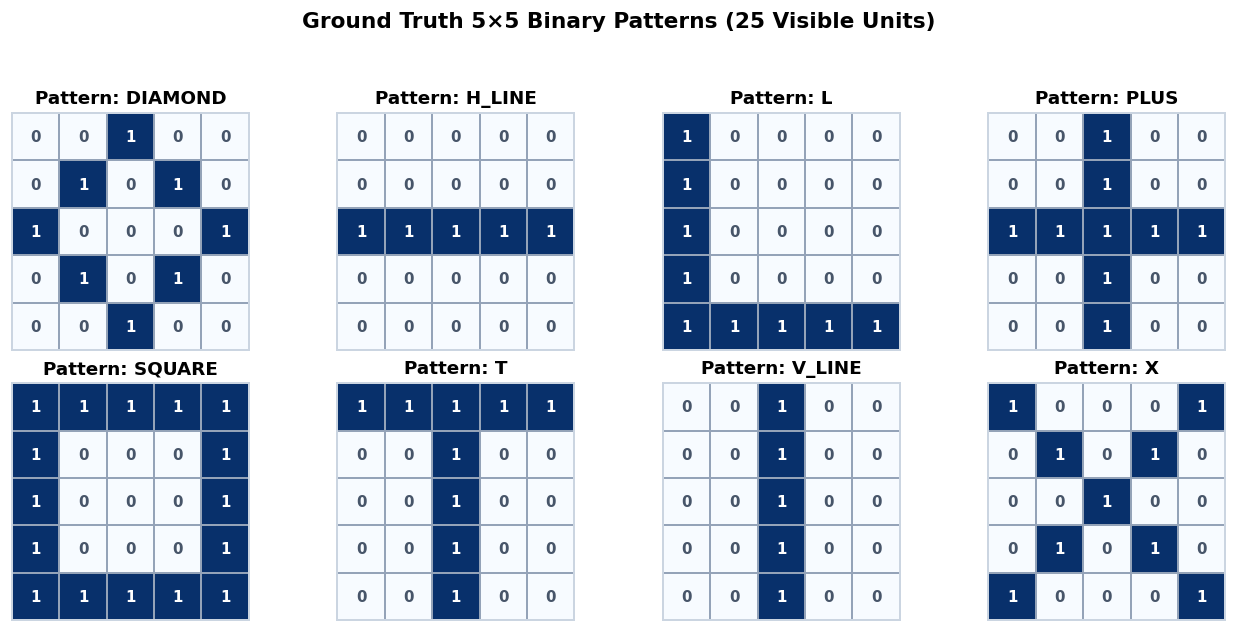

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(11, 5.5))
fig.suptitle("Ground Truth 5×5 Binary Patterns (25 Visible Units)", fontsize=13, fontweight='bold', y=0.98)

for idx, name in enumerate(pattern_names):
    ax = axes[idx // 4, idx % 4]
    grid = canonical_dict[name].reshape(5, 5)
    ax.imshow(grid, cmap='Blues', vmin=0, vmax=1, interpolation='nearest')
    
    for r in range(5):
        for c in range(5):
            val = int(grid[r, c])
            ax.text(c, r, str(val), ha='center', va='center', fontsize=9, 
                    fontweight='bold', color='white' if val == 1 else '#475569')
            
    ax.set_title(f"Pattern: {name}", fontsize=11, fontweight='bold', pad=6)
    ax.set_xticks(np.arange(-0.5, 5, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 5, 1), minor=True)
    ax.grid(which='minor', color='#94a3b8', linestyle='-', linewidth=1.2)
    ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()


## ⚙️ Step 4: Restricted Boltzmann Machine Implementation (NumPy)

In [4]:
class RestrictedBoltzmannMachine:
    def __init__(self, n_visible=25, n_hidden=24, learning_rate=0.04, 
                 momentum=0.5, weight_decay=0.0001, random_state=42):
        self.n_visible = n_visible
        self.n_hidden = n_hidden
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.weight_decay = weight_decay
        self.rng = np.random.RandomState(random_state)
        
        self.W = self.rng.normal(0.0, 0.05, size=(n_visible, n_hidden))
        self.a = np.zeros(n_visible)
        self.b = np.zeros(n_hidden)
        
        self.v_W = np.zeros_like(self.W)
        self.v_a = np.zeros_like(self.a)
        self.v_b = np.zeros_like(self.b)
        
        self.history = {
            'epoch': [],
            'mean_squared_error': [],
            'reconstruction_loss_bce': [],
            'free_energy': []
        }

    @staticmethod
    def sigmoid(z):
        z_clipped = np.clip(z, -30.0, 30.0)
        return 1.0 / (1.0 + np.exp(-z_clipped))

    def sample_bernoulli(self, probabilities):
        return (self.rng.rand(*probabilities.shape) < probabilities).astype(np.float64)

    def propagate_up(self, v):
        h_probs = self.sigmoid(np.dot(v, self.W) + self.b)
        h_states = self.sample_bernoulli(h_probs)
        return h_probs, h_states

    def propagate_down(self, h):
        v_probs = self.sigmoid(np.dot(h, self.W.T) + self.a)
        v_states = self.sample_bernoulli(v_probs)
        return v_probs, v_states

    def free_energy(self, v):
        v_bias_term = np.dot(v, self.a)
        wx_b = np.dot(v, self.W) + self.b
        hidden_term = np.sum(np.log1p(np.exp(np.clip(wx_b, -30.0, 30.0))), axis=-1)
        return -v_bias_term - hidden_term

    def contrastive_divergence(self, v_batch, k=1):
        batch_size = v_batch.shape[0]
        
        # Positive Phase
        h_probs_0, h_states_0 = self.propagate_up(v_batch)
        pos_associations = np.dot(v_batch.T, h_probs_0)
        
        # Negative Phase (Gibbs sampling)
        v_current = v_batch
        h_current = h_states_0
        for _ in range(k):
            v_probs_k, v_states_k = self.propagate_down(h_current)
            h_probs_k, h_states_k = self.propagate_up(v_states_k)
            v_current = v_states_k
            h_current = h_states_k
            
        neg_associations = np.dot(v_current.T, h_probs_k)
        
        # Gradients
        dW = (pos_associations - neg_associations) / batch_size - self.weight_decay * self.W
        da = np.mean(v_batch - v_current, axis=0)
        db = np.mean(h_probs_0 - h_probs_k, axis=0)
        
        # Momentum Updates
        self.v_W = self.momentum * self.v_W + self.learning_rate * dW
        self.v_a = self.momentum * self.v_a + self.learning_rate * da
        self.v_b = self.momentum * self.v_b + self.learning_rate * db
        
        self.W += self.v_W
        self.a += self.v_a
        self.b += self.v_b
        
        return np.mean((v_batch - v_probs_k) ** 2)

    def fit(self, X_train, n_epochs=500, batch_size=16, k=1, verbose=True):
        n_samples = X_train.shape[0]
        for epoch in range(1, n_epochs + 1):
            self.momentum = 0.90 if epoch > 30 else 0.50
            indices = self.rng.permutation(n_samples)
            X_shuffled = X_train[indices]
            
            for i in range(0, n_samples, batch_size):
                v_batch = X_shuffled[i:i + batch_size]
                self.contrastive_divergence(v_batch, k=k)
            
            recon_probs, _ = self.reconstruct(X_train, steps=1, return_probabilities=True)
            epoch_mse = np.mean((X_train - recon_probs) ** 2)
            epoch_bce = -np.mean(X_train * np.log(np.clip(recon_probs, 1e-10, 1.0)) + 
                                 (1.0 - X_train) * np.log(np.clip(1.0 - recon_probs, 1e-10, 1.0)))
            avg_fe = np.mean(self.free_energy(X_train))
            
            self.history['epoch'].append(epoch)
            self.history['mean_squared_error'].append(epoch_mse)
            self.history['reconstruction_loss_bce'].append(epoch_bce)
            self.history['free_energy'].append(avg_fe)
            
            if verbose and (epoch % 100 == 0 or epoch == 1 or epoch == n_epochs):
                print(f"Epoch [{epoch:3d}/{n_epochs:3d}] | MSE: {epoch_mse:.5f} | BCE: {epoch_bce:.4f} | Free Energy: {avg_fe:.2f}")
        return self.history

    def reconstruct(self, v_input, steps=5, return_probabilities=True):
        v_curr = np.copy(v_input)
        for _ in range(steps):
            h_probs, _ = self.propagate_up(v_curr)
            v_probs, _ = self.propagate_down(h_probs)
            v_curr = v_probs
        
        binary_out = (v_probs >= 0.5).astype(np.float64)
        if return_probabilities:
            return v_probs, binary_out
        return binary_out


## 🏋️ Step 5: Training the RBM on Clean Patterns

In [5]:
# Prepare clean training data
clean_patterns = list(canonical_dict.values())
X_train_list = []
for p in clean_patterns:
    for _ in range(25):
        X_train_list.append(p.copy())
    for pixel_idx in range(25):
        variant = p.copy()
        variant[pixel_idx] = 1.0 - variant[pixel_idx]
        X_train_list.append(variant)

X_train = np.array(X_train_list, dtype=np.float64)
print(f"Prepared {X_train.shape[0]} training patterns.")

rbm = RestrictedBoltzmannMachine(
    n_visible=25,
    n_hidden=24,
    learning_rate=0.04,
    momentum=0.5,
    weight_decay=0.0001,
    random_state=SEED
)

history = rbm.fit(X_train, n_epochs=500, batch_size=16, k=1, verbose=True)


Prepared 400 training patterns.
Epoch [  1/500] | MSE: 0.19835 | BCE: 0.5809 | Free Energy: -14.24


Epoch [100/500] | MSE: 0.01886 | BCE: 0.0856 | Free Energy: -43.14


Epoch [200/500] | MSE: 0.01881 | BCE: 0.0839 | Free Energy: -43.79


Epoch [300/500] | MSE: 0.01882 | BCE: 0.0839 | Free Energy: -42.52


Epoch [400/500] | MSE: 0.01879 | BCE: 0.0835 | Free Energy: -42.27


Epoch [500/500] | MSE: 0.01885 | BCE: 0.0839 | Free Energy: -42.22


## 📈 Step 6: Training Loss Curves & Free Energy

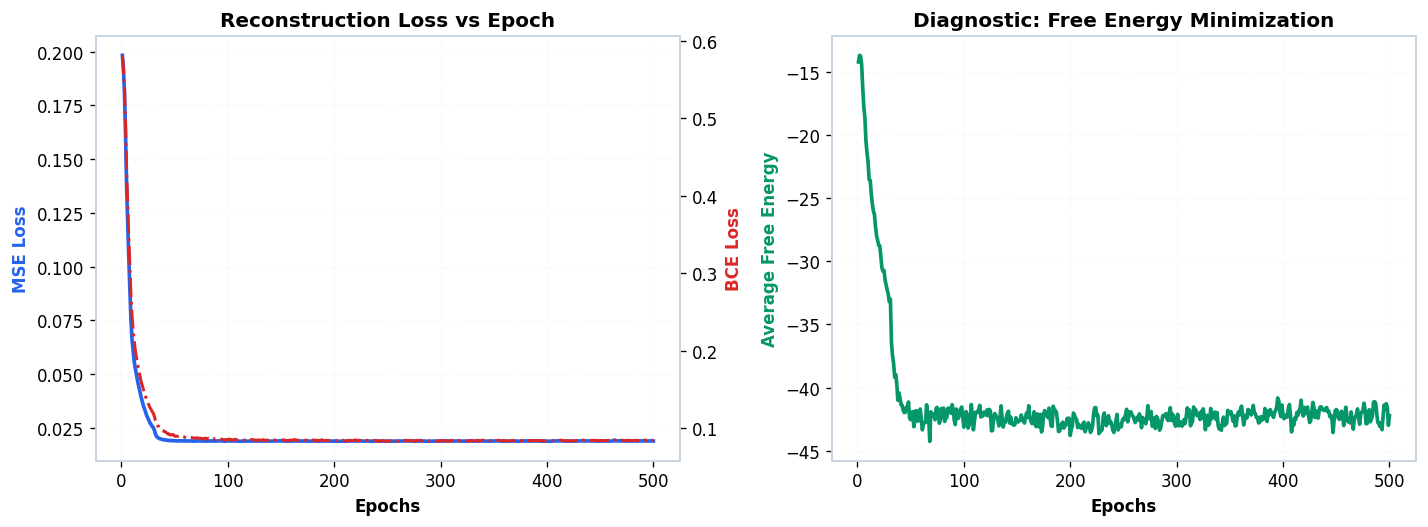

In [6]:
epochs = history['epoch']
mse = history['mean_squared_error']
bce = history['reconstruction_loss_bce']
fe = history['free_energy']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Subplot 1: MSE & BCE Loss
ax1.plot(epochs, mse, color='#2563eb', lw=2.2, label='Mean Squared Error (MSE)')
ax1.set_xlabel('Epochs', fontweight='bold')
ax1.set_ylabel('MSE Loss', color='#2563eb', fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)

ax1_t = ax1.twinx()
ax1_t.plot(epochs, bce, color='#dc2626', lw=1.8, linestyle='-.', label='Cross-Entropy (BCE)')
ax1_t.set_ylabel('BCE Loss', color='#dc2626', fontweight='bold')
ax1.set_title("Reconstruction Loss vs Epoch", fontweight='bold')

# Subplot 2: Free Energy
ax2.plot(epochs, fe, color='#059669', lw=2.2, label='Free Energy F(v)')
ax2.set_xlabel('Epochs', fontweight='bold')
ax2.set_ylabel('Average Free Energy', color='#059669', fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_title("Diagnostic: Free Energy Minimization", fontweight='bold')

plt.tight_layout()
plt.show()


## 🌪️ Step 7: Inject 20% Controlled Bit-Flip Noise AFTER Training

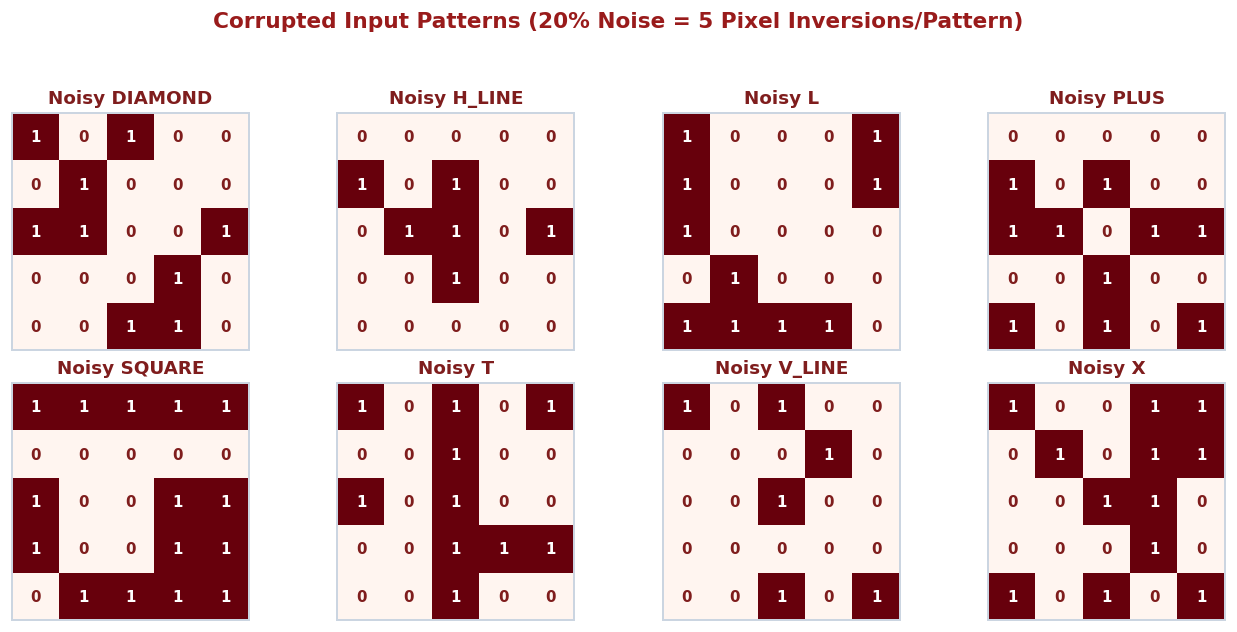

In [7]:
def add_controlled_noise(clean_matrix, noise_fraction=0.20, seed=42):
    rng = np.random.RandomState(seed)
    noisy_matrix = np.copy(clean_matrix)
    n_samples, n_pixels = clean_matrix.shape
    k_flips = int(round(noise_fraction * n_pixels))
    for i in range(n_samples):
        flip_indices = rng.choice(n_pixels, size=k_flips, replace=False)
        noisy_matrix[i, flip_indices] = 1.0 - noisy_matrix[i, flip_indices]
    return noisy_matrix, k_flips

canonical_X = np.array([canonical_dict[p] for p in pattern_names])
noisy_canonical_X, k_flips = add_controlled_noise(canonical_X, noise_fraction=0.20, seed=SEED)
noisy_dict = {p: noisy_canonical_X[idx] for idx, p in enumerate(pattern_names)}

fig, axes = plt.subplots(2, 4, figsize=(11, 5.5))
fig.suptitle(f"Corrupted Input Patterns (20% Noise = {k_flips} Pixel Inversions/Pattern)", 
             fontsize=13, fontweight='bold', y=0.98, color='#991b1b')

for idx, name in enumerate(pattern_names):
    ax = axes[idx // 4, idx % 4]
    grid = noisy_dict[name].reshape(5, 5)
    ax.imshow(grid, cmap='Reds', vmin=0, vmax=1, interpolation='nearest')
    for r in range(5):
        for c in range(5):
            val = int(grid[r, c])
            ax.text(c, r, str(val), ha='center', va='center', fontsize=9, 
                    fontweight='bold', color='white' if val == 1 else '#7f1d1d')
    ax.set_title(f"Noisy {name}", fontsize=11, fontweight='bold', pad=6, color='#7f1d1d')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()


## 🎯 Step 8: RBM Denoising & Associative Pattern Reconstruction

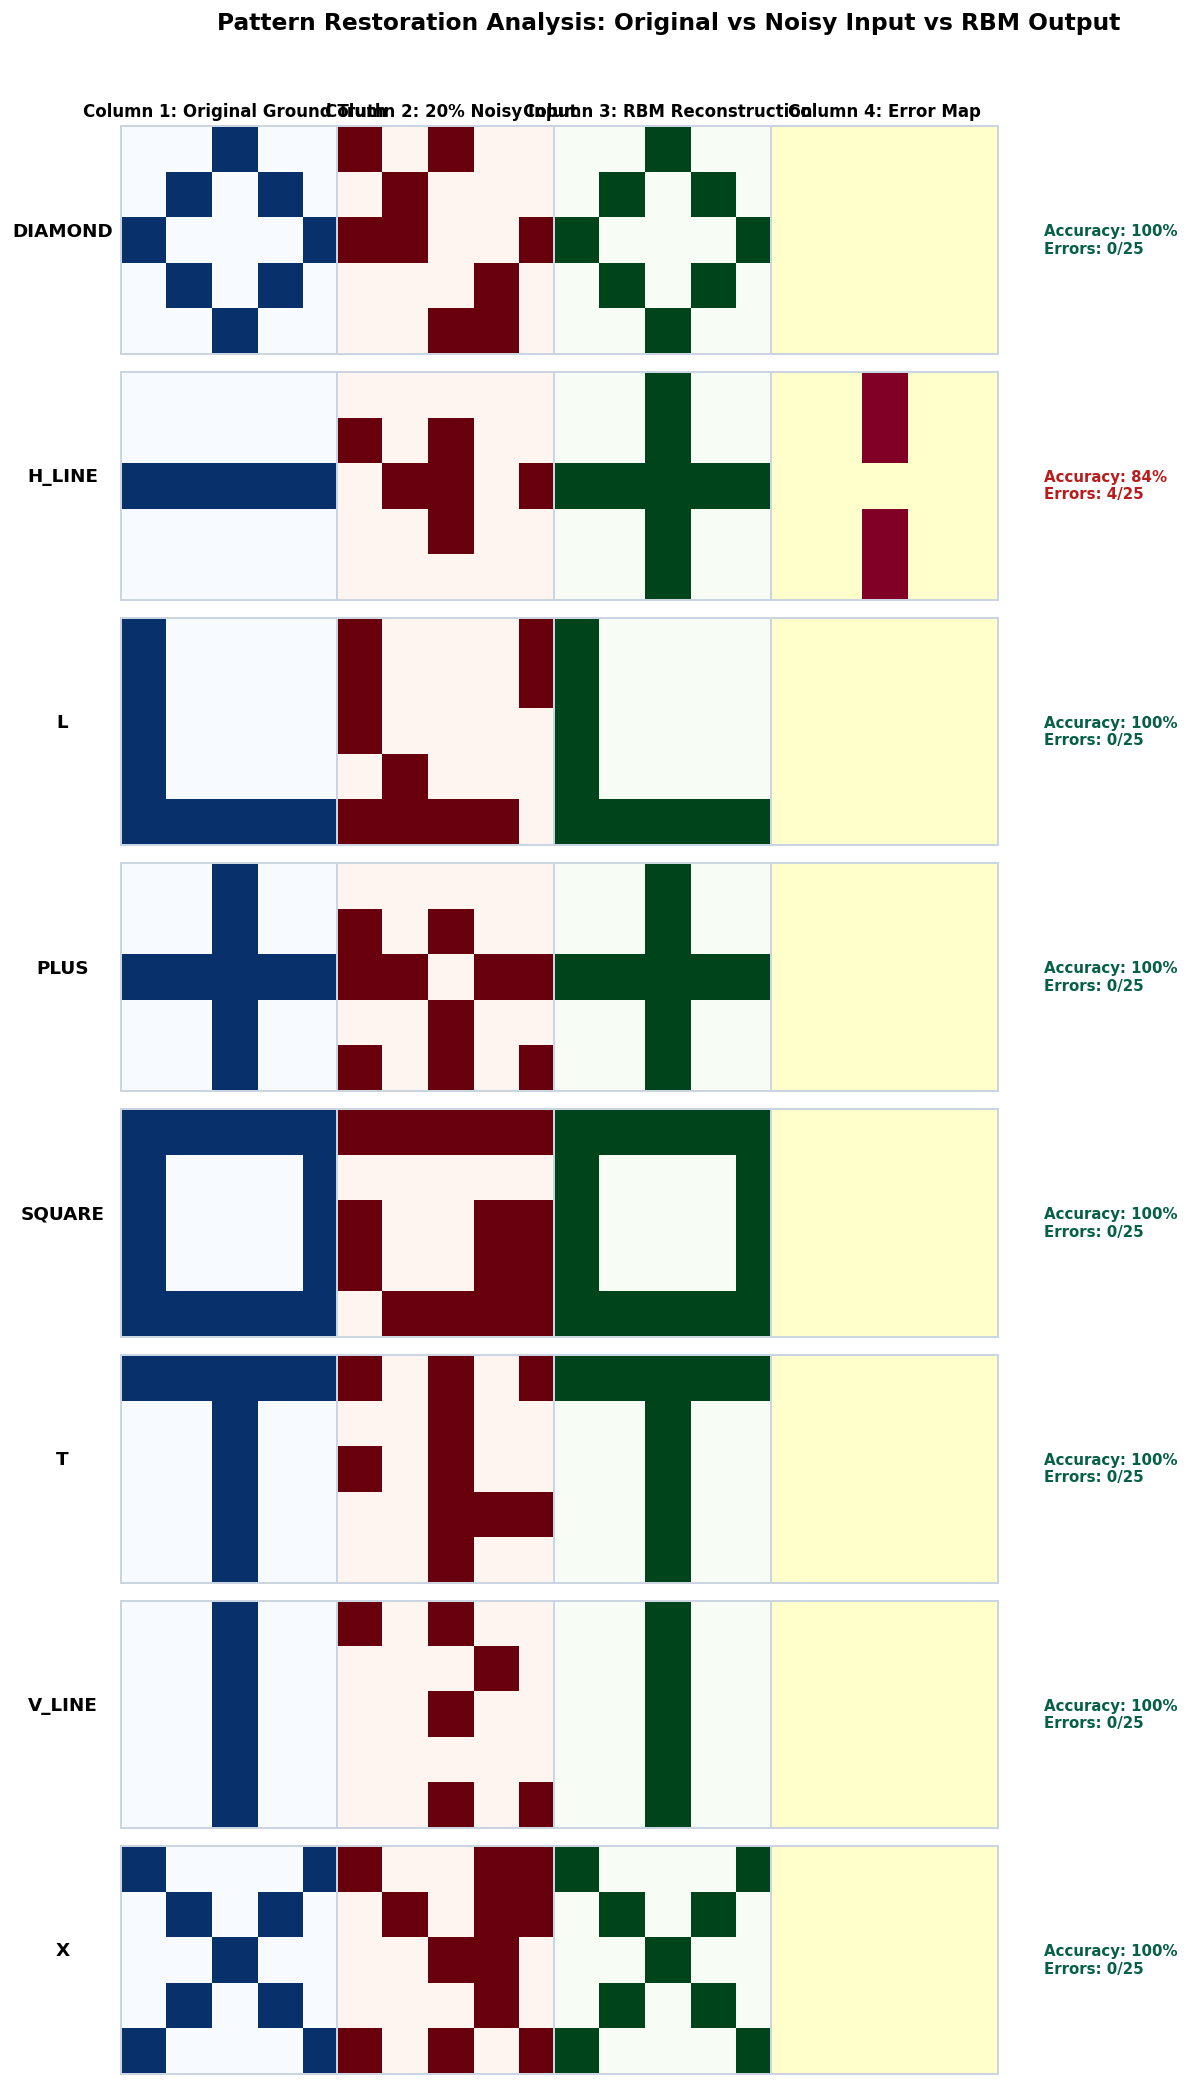

In [8]:
recon_probs, recon_binary = rbm.reconstruct(noisy_canonical_X, steps=5, return_probabilities=True)
recon_dict = {p: recon_binary[idx] for idx, p in enumerate(pattern_names)}

fig, axes = plt.subplots(len(pattern_names), 4, figsize=(11, 2.2 * len(pattern_names)))
fig.suptitle("Pattern Restoration Analysis: Original vs Noisy Input vs RBM Output", 
             fontsize=14, fontweight='bold', y=0.995)

for idx, name in enumerate(pattern_names):
    orig = canonical_dict[name].reshape(5, 5)
    noisy = noisy_dict[name].reshape(5, 5)
    recon = recon_dict[name].reshape(5, 5)
    diff = np.abs(orig - recon)
    
    acc = np.mean(orig == recon) * 100
    errors = int(np.sum(orig != recon))
    
    axes[idx, 0].imshow(orig, cmap='Blues', vmin=0, vmax=1)
    axes[idx, 0].set_ylabel(name, fontweight='bold', fontsize=11, rotation=0, labelpad=35)
    
    axes[idx, 1].imshow(noisy, cmap='Reds', vmin=0, vmax=1)
    axes[idx, 2].imshow(recon, cmap='Greens', vmin=0, vmax=1)
    axes[idx, 3].imshow(diff, cmap='YlOrRd', vmin=0, vmax=1)
    
    axes[idx, 3].text(5.5, 2.0, f"Accuracy: {acc:.0f}%\nErrors: {errors}/25", fontsize=9, fontweight='bold',
                      color='#065f46' if errors == 0 else '#b91c1c', va='center')
    
    for ax in axes[idx]:
        ax.set_xticks([])
        ax.set_yticks([])

axes[0, 0].set_title("Column 1: Original Ground Truth", fontweight='bold', fontsize=10)
axes[0, 1].set_title("Column 2: 20% Noisy Input", fontweight='bold', fontsize=10)
axes[0, 2].set_title("Column 3: RBM Reconstruction", fontweight='bold', fontsize=10)
axes[0, 3].set_title("Column 4: Error Map", fontweight='bold', fontsize=10)

plt.tight_layout(rect=[0, 0.01, 0.88, 0.98])
plt.show()


## 📋 Step 9: Quantitative Performance Evaluation Table

In [9]:
table_rows = []
for idx, p in enumerate(pattern_names):
    orig = canonical_X[idx]
    noisy = noisy_canonical_X[idx]
    recon = recon_binary[idx]
    
    noisy_acc = np.mean(orig == noisy) * 100.0
    recon_acc = np.mean(orig == recon) * 100.0
    noisy_errs = int(np.sum(orig != noisy))
    recon_errs = int(np.sum(orig != recon))
    mse_val = np.mean((orig - recon) ** 2)
    gain = recon_acc - noisy_acc
    
    table_rows.append({
        'Pattern': p,
        'Initial Noisy Acc (%)': f"{noisy_acc:.1f}%",
        'RBM Recon Acc (%)': f"{recon_acc:.1f}%",
        'Noisy Incorrect Pixels': f"{noisy_errs}/25",
        'Recon Incorrect Pixels': f"{recon_errs}/25",
        'Mean Squared Error': round(mse_val, 4),
        'Accuracy Recovery Gain': f"+{gain:.1f}%" if gain >= 0 else f"{gain:.1f}%"
    })

metrics_df = pd.DataFrame(table_rows)
display(metrics_df)

overall_noisy_acc = np.mean(canonical_X == noisy_canonical_X) * 100.0
overall_recon_acc = np.mean(canonical_X == recon_binary) * 100.0
print(f"\nOverall Initial Corrupted Accuracy:  {overall_noisy_acc:.2f}%")
print(f"Overall RBM Reconstructed Accuracy:  {overall_recon_acc:.2f}%")
print(f"Net Accuracy Recovery Gain:          +{overall_recon_acc - overall_noisy_acc:.2f}%")


,Pattern,Initial Noisy Acc (%),RBM Recon Acc (%),Noisy Incorrect Pixels,Recon Incorrect Pixels,Mean Squared Error,Accuracy Recovery Gain
0,DIAMOND,80.0%,100.0%,5/25,0/25,0.00,+20.0%
1,H_LINE,80.0%,84.0%,5/25,4/25,0.16,+4.0%
2,L,80.0%,100.0%,5/25,0/25,0.00,+20.0%
3,PLUS,80.0%,100.0%,5/25,0/25,0.00,+20.0%
4,SQUARE,80.0%,100.0%,5/25,0/25,0.00,+20.0%
5,T,80.0%,100.0%,5/25,0/25,0.00,+20.0%
6,V_LINE,80.0%,100.0%,5/25,0/25,0.00,+20.0%
7,X,80.0%,100.0%,5/25,0/25,0.00,+20.0%



Overall Initial Corrupted Accuracy:  80.00%
Overall RBM Reconstructed Accuracy:  98.00%
Net Accuracy Recovery Gain:          +18.00%


## 🎓 Step 10: Viva Voce & Academic Q&A Preparation

### Key Viva Questions & Clear Answers:

1. **Q: What is a Restricted Boltzmann Machine (RBM)?**
   * **A:** An RBM is an energy-based, undirected bipartite generative stochastic neural network consisting of visible units (representing data features) and hidden units (representing latent features), with connections strictly restricted to visible-hidden pairs.

2. **Q: Why are there 25 visible units in this project?**
   * **A:** Each binary pattern is represented on a $5 \times 5$ pixel grid. Each pixel corresponds directly to one visible unit ($5 \times 5 = 25$).

3. **Q: What are hidden units and what role do they play?**
   * **A:** Hidden units are latent stochastic binary variables that capture high-order correlations, strokes, and geometric features among the visible pixels.

4. **Q: Why do we intentionally introduce noise AFTER training?**
   * **A:** Noise is added after training to rigorously test the RBM's generative and associative memory capabilities—specifically, whether the network has learned deep energy attractors that can clean and reconstruct corrupted inputs without simply memorizing pixels.

5. **Q: What is Contrastive Divergence (CD-1)?**
   * **A:** Contrastive Divergence is an efficient learning algorithm that approximates the intractable negative phase gradient of log-likelihood by running a 1-step Gibbs chain initialized from the training data.

6. **Q: What does reconstruction accuracy mean?**
   * **A:** Reconstruction accuracy measures the percentage of binary pixels in the RBM output that exactly match the pristine clean ground-truth pattern ($100 \times \frac{\text{correct pixels}}{25}$).
